In [ ]:
import kagglehub
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import os


# Descargar el dataset
path = kagglehub.dataset_download("imakash3011/customer-personality-analysis")
print("Path to dataset files:", path)

# Buscar y leer el archivo CSV
dataset_folder = path
csv_file = None
for file in os.listdir(dataset_folder):
    if file.endswith(".csv"):
        csv_file = os.path.join(dataset_folder, file)
        break

if not csv_file:
    print("No se encontró un archivo CSV.")
    exit()

/Users/cgomezfandino/repos/machineLearning/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/cgomezfandino/.cache/kagglehub/datasets/imakash3011/customer-personality-analysis/versions/1


In [2]:
# Leer el dataset
df = pd.read_csv(csv_file, sep="\t")    
# Limpieza: Eliminar filas con valores nulos y columnas no relevantes
df = df.dropna()
df = df.drop(['ID', 'Dt_Customer'], axis=1, errors='ignore')  # Eliminar ID y fecha
df = pd.get_dummies(df, columns=['Education', 'Marital_Status'], drop_first=False, dtype=int)
print(df.columns)
df.head()

Index(['Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines',
       'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Education_2n Cycle', 'Education_Basic', 'Education_Graduation',
       'Education_Master', 'Education_PhD', 'Marital_Status_Absurd',
       'Marital_Status_Alone', 'Marital_Status_Divorced',
       'Marital_Status_Married', 'Marital_Status_Single',
       'Marital_Status_Together', 'Marital_Status_Widow',
       'Marital_Status_YOLO'],
      dtype='object')


,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,Education_Master,Education_PhD,Marital_Status_Absurd,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO
0,1957,58138.0,0,0,58,635,88,546,172,88,...,0,0,0,0,0,0,1,0,0,0
1,1954,46344.0,1,1,38,11,1,6,2,1,...,0,0,0,0,0,0,1,0,0,0
2,1965,71613.0,0,0,26,426,49,127,111,21,...,0,0,0,0,0,0,0,1,0,0
3,1984,26646.0,1,0,26,11,4,20,10,3,...,0,0,0,0,0,0,0,1,0,0
4,1981,58293.0,1,0,94,173,43,118,46,27,...,0,1,0,0,0,1,0,0,0,0


In [3]:
df.describe()

,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,Education_Master,Education_PhD,Marital_Status_Absurd,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO
count,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,...,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000
mean,1968.820397,52247.251354,0.441787,0.505415,49.012635,305.091606,26.356047,166.995939,37.637635,27.028881,...,0.164711,0.217058,0.000903,0.001354,0.104693,0.386733,0.212545,0.258574,0.034296,0.000903
std,11.985554,25173.076661,0.536896,0.544181,28.948352,337.327920,39.793917,224.283273,54.752082,41.072046,...,0.371003,0.412335,0.030035,0.036777,0.306227,0.487112,0.409201,0.437950,0.182030,0.030035
min,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1959.000000,35303.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1970.000000,51381.500000,0.000000,0.000000,49.000000,174.500000,8.000000,68.000000,12.000000,8.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1977.000000,68522.000000,1.000000,1.000000,74.000000,505.000000,33.000000,232.250000,50.000000,33.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000
max,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,262.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


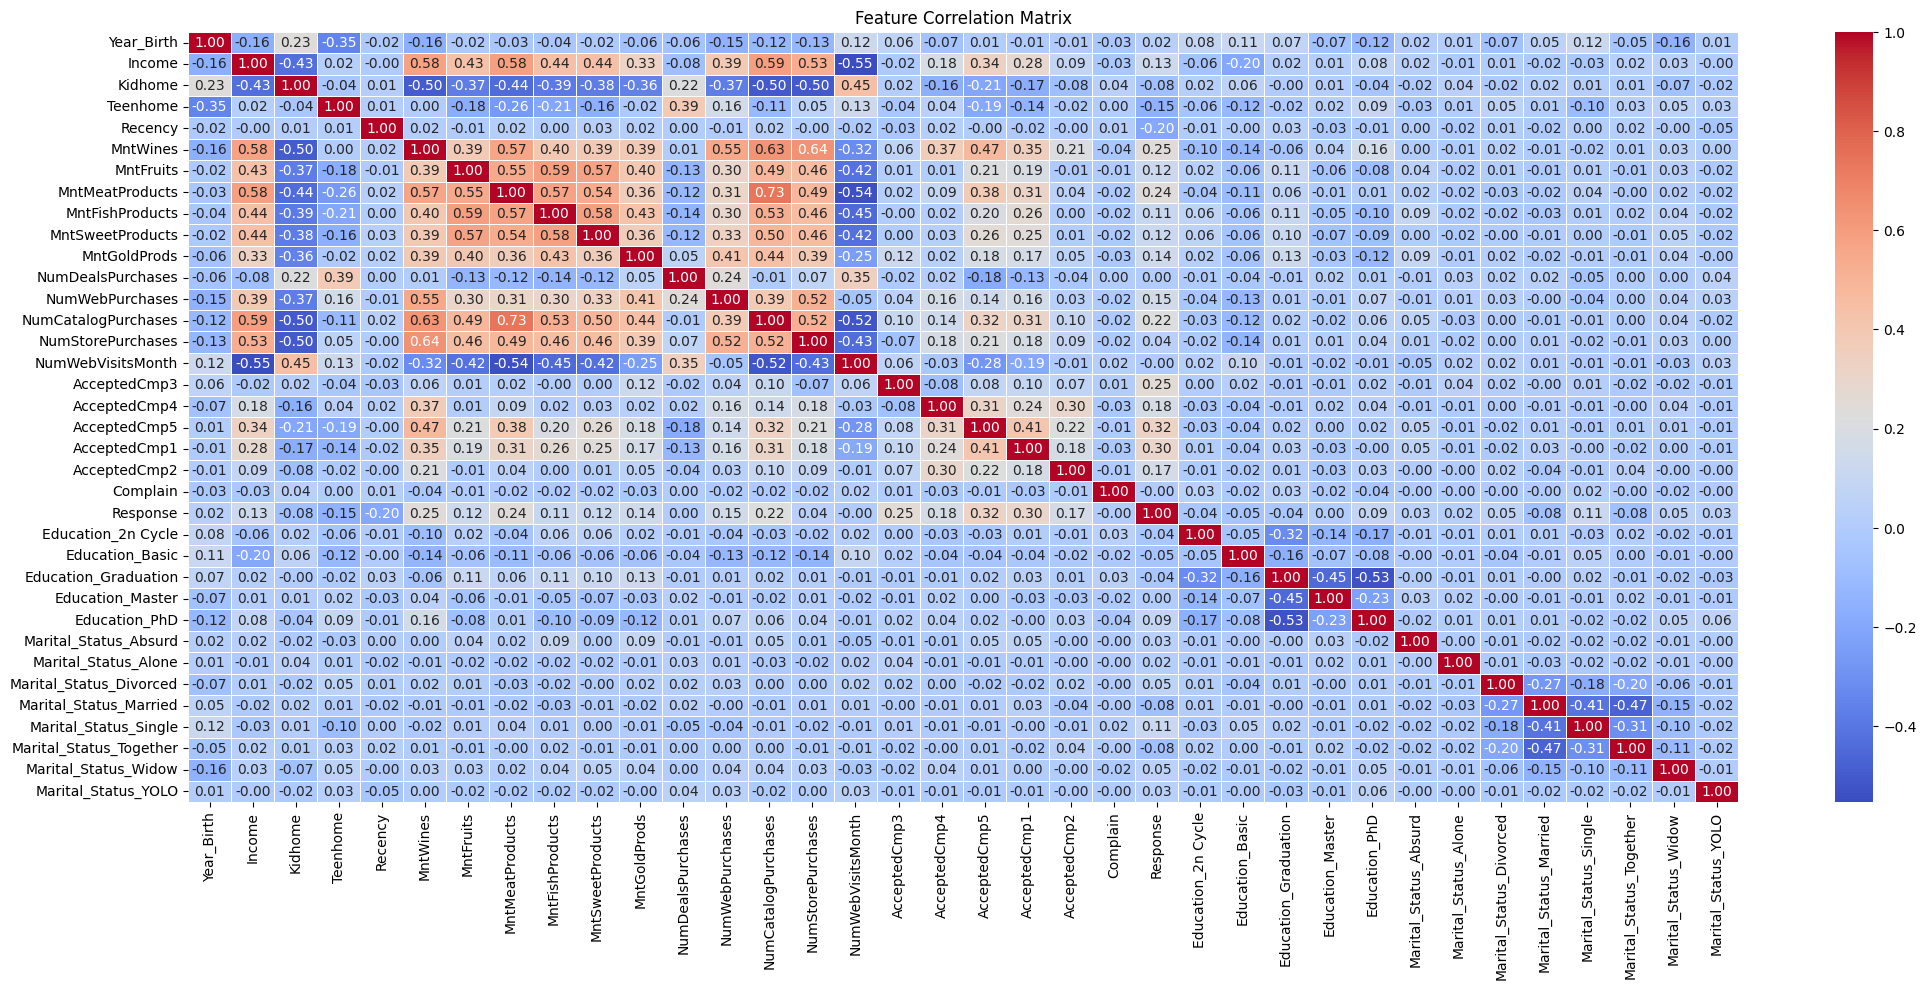

In [4]:
# correlation_matrix = df[col_features].corr()
correlation_matrix = df.drop(['Z_CostContact', 'Z_Revenue'], axis=1).corr()
# Plot the heatmap
plt.figure(figsize=(25, 10))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5) ##cmap=["coolwarm", "viridis", "plasma", "inferno", "magma", "cividis"]

plt.title("Feature Correlation Matrix")
plt.show()

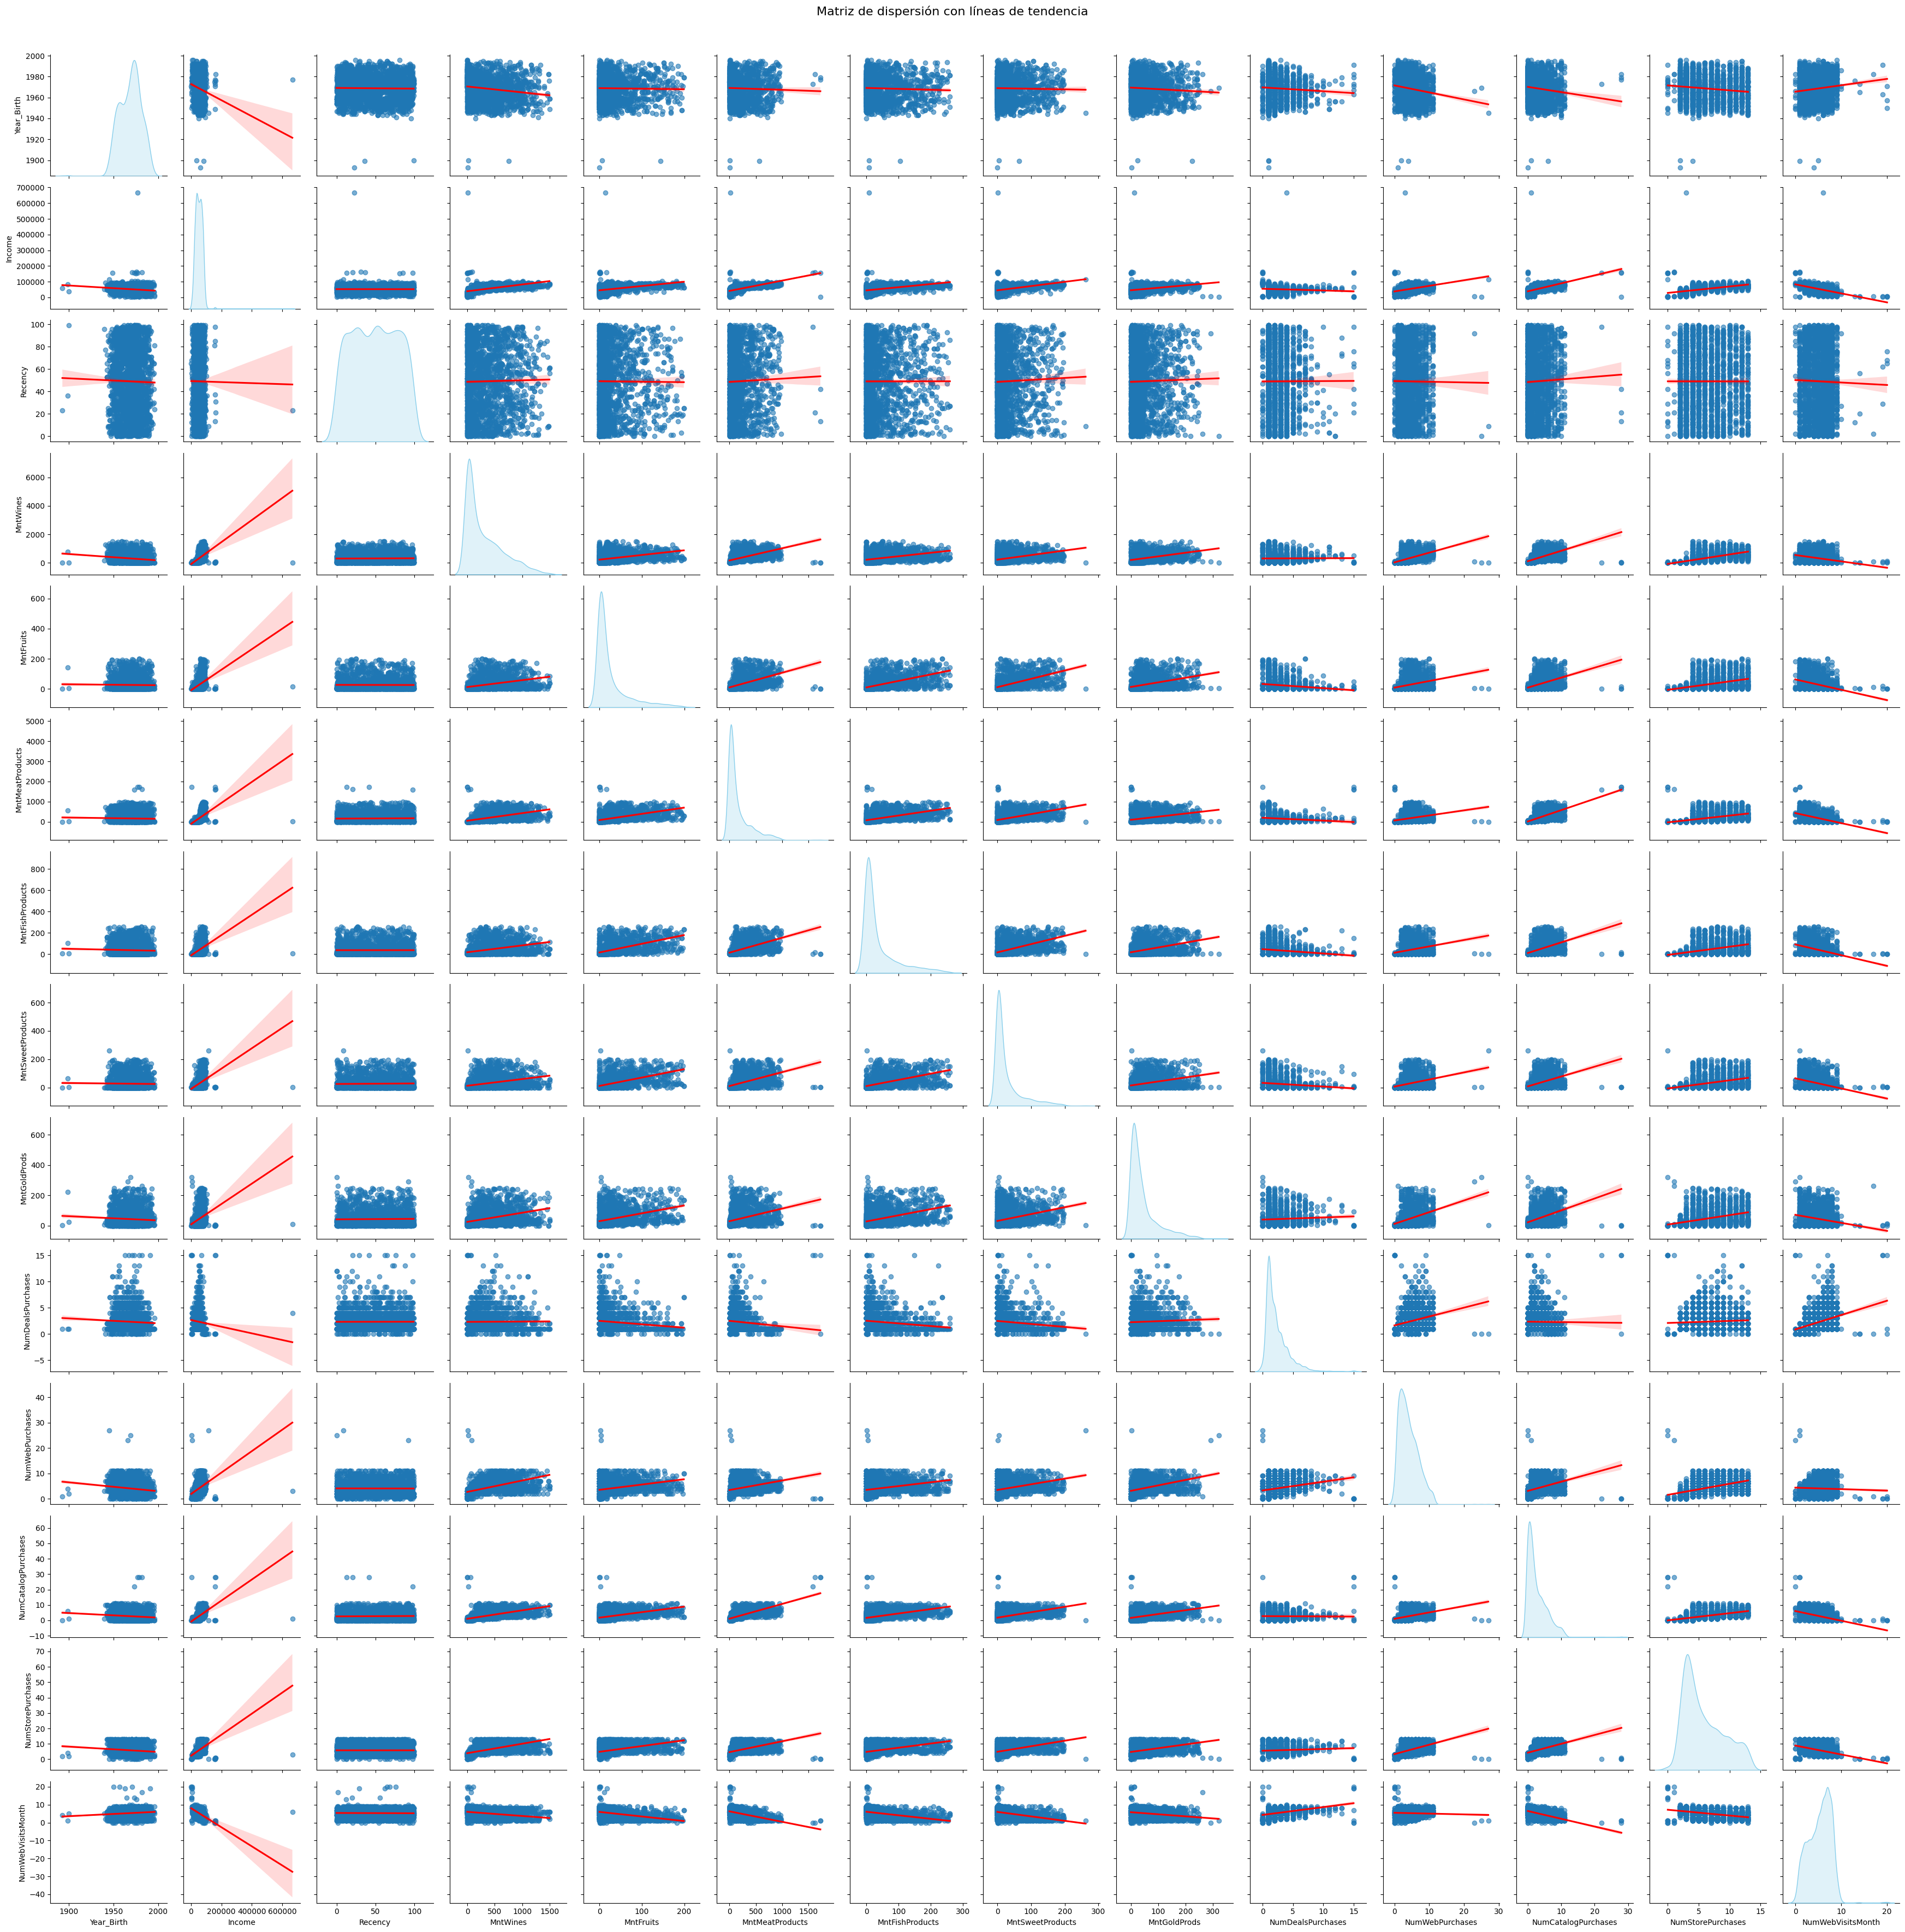

In [5]:
# Supón que tus variables numéricas están en el DataFrame 'df'
# Puedes especificar solo ciertas columnas si quieres: df = df[['var1', 'var2', 'var3']]
cols = ['Year_Birth', 'Income', 'Recency', 'MntWines',
       'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth']


# Crea un PairGrid con tus variables
g = sns.PairGrid(df[cols], diag_sharey=False)

# Diagonal: distribución univariada (histograma o kde)
g.map_diag(sns.kdeplot , fill=True, color='skyblue')   # Usa sns.kdeplot si prefieres densidad, sns.histplot

# Fuera de la diagonal: scatterplot + línea de tendencia
g.map_offdiag(sns.regplot, scatter_kws={'alpha':0.6}, line_kws={"color":"red"})

# Títulos y espacio
plt.suptitle("Matriz de dispersión con líneas de tendencia", y=1.01, fontsize=16)
plt.tight_layout()
plt.show()

In [6]:

# Estandarizar los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
X_scaled

array([[-0.98644293,  0.2340627 , -0.82303932, ..., -0.59055252,
        -0.18845163, -0.03005565],
       [-1.23680074, -0.23455948,  1.03993835, ..., -0.59055252,
        -0.18845163, -0.03005565],
       [-0.31882209,  0.76947764, -0.82303932, ...,  1.69332949,
        -0.18845163, -0.03005565],
       ...,
       [ 1.01641959,  0.18809052, -0.82303932, ..., -0.59055252,
        -0.18845163, -0.03005565],
       [-1.06989553,  0.67538765, -0.82303932, ...,  1.69332949,
        -0.18845163, -0.03005565],
       [-1.23680074,  0.02470453,  1.03993835, ..., -0.59055252,
        -0.18845163, -0.03005565]], shape=(2216, 38))

In [7]:

# Aplicar PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print("Varianza explicada por cada componente:", pca.explained_variance_ratio_)
print("Varianza total explicada:", sum(pca.explained_variance_ratio_))

Varianza explicada por cada componente: [0.18277308 0.06153123]
Varianza total explicada: 0.24430430723396418


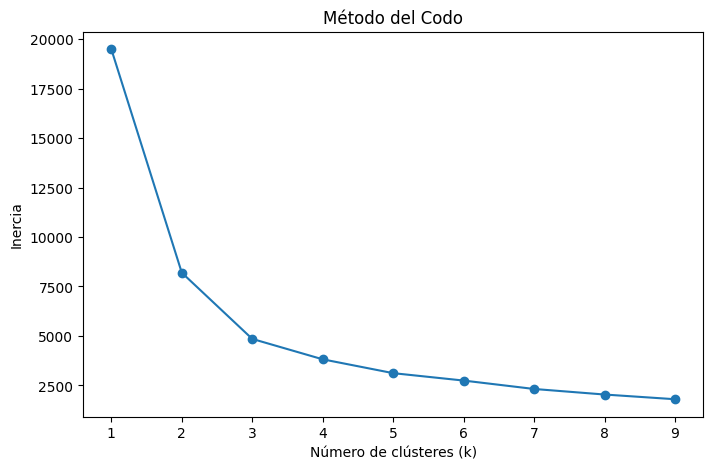

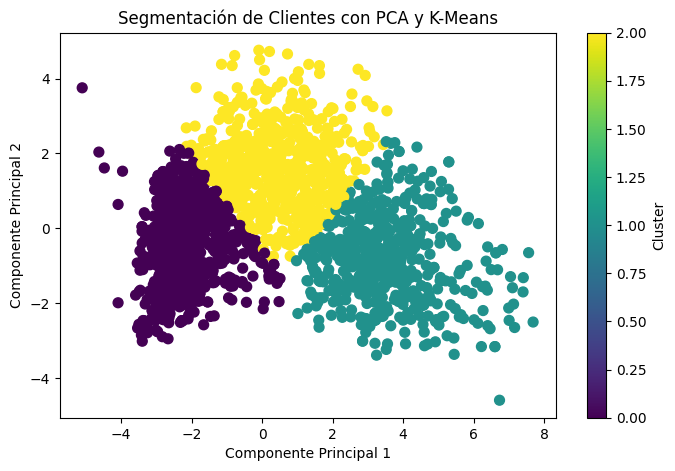

In [9]:

# Método del codo para elegir k
inertias = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_pca)
    inertias.append(kmeans.inertia_)

# Graficar el método del codo
plt.figure(figsize=(8, 5))
plt.plot(range(1, 10), inertias, marker='o')
plt.xlabel('Número de clústeres (k)')
plt.ylabel('Inercia')
plt.title('Método del Codo')
plt.show()

# Aplicar K-Means (suponiendo k=3 basado en el codo)
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_pca)
df['Cluster'] = clusters

# Visualizar los clústeres
plt.figure(figsize=(8, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', s=50)
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('Segmentación de Clientes con PCA y K-Means')
plt.colorbar(label='Cluster')
plt.show()

In [10]:
# Estadísticas por clúster
print("Estadísticas por clúster:")
df.groupby('Cluster').mean()

Estadísticas por clúster:


,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,Education_Master,Education_PhD,Marital_Status_Absurd,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO
Cluster,,,,,,,,,,,,,,,,,,,,,
0,1972.268482,34660.864786,0.801556,0.430934,49.368677,43.361868,5.855058,25.764591,8.485409,5.645914,...,0.152724,0.164397,0.000000,0.001946,0.090467,0.393969,0.237354,0.256809,0.019455,0.000000
1,1968.837743,77294.333333,0.047619,0.178131,49.345679,602.977072,69.989418,458.703704,101.206349,71.657848,...,0.132275,0.174603,0.003527,0.000000,0.089947,0.368607,0.245150,0.253968,0.038801,0.000000
2,1963.096618,58490.584541,0.206119,0.927536,48.119163,466.375201,20.454106,134.447665,27.855072,21.677939,...,0.214171,0.342995,0.000000,0.001610,0.141707,0.391304,0.141707,0.265700,0.054750,0.003221


In [15]:
from sklearn.metrics import silhouette_score
print("Silhouette Score:", round(silhouette_score(X_pca, clusters), 2))

Silhouette Score: 0.48


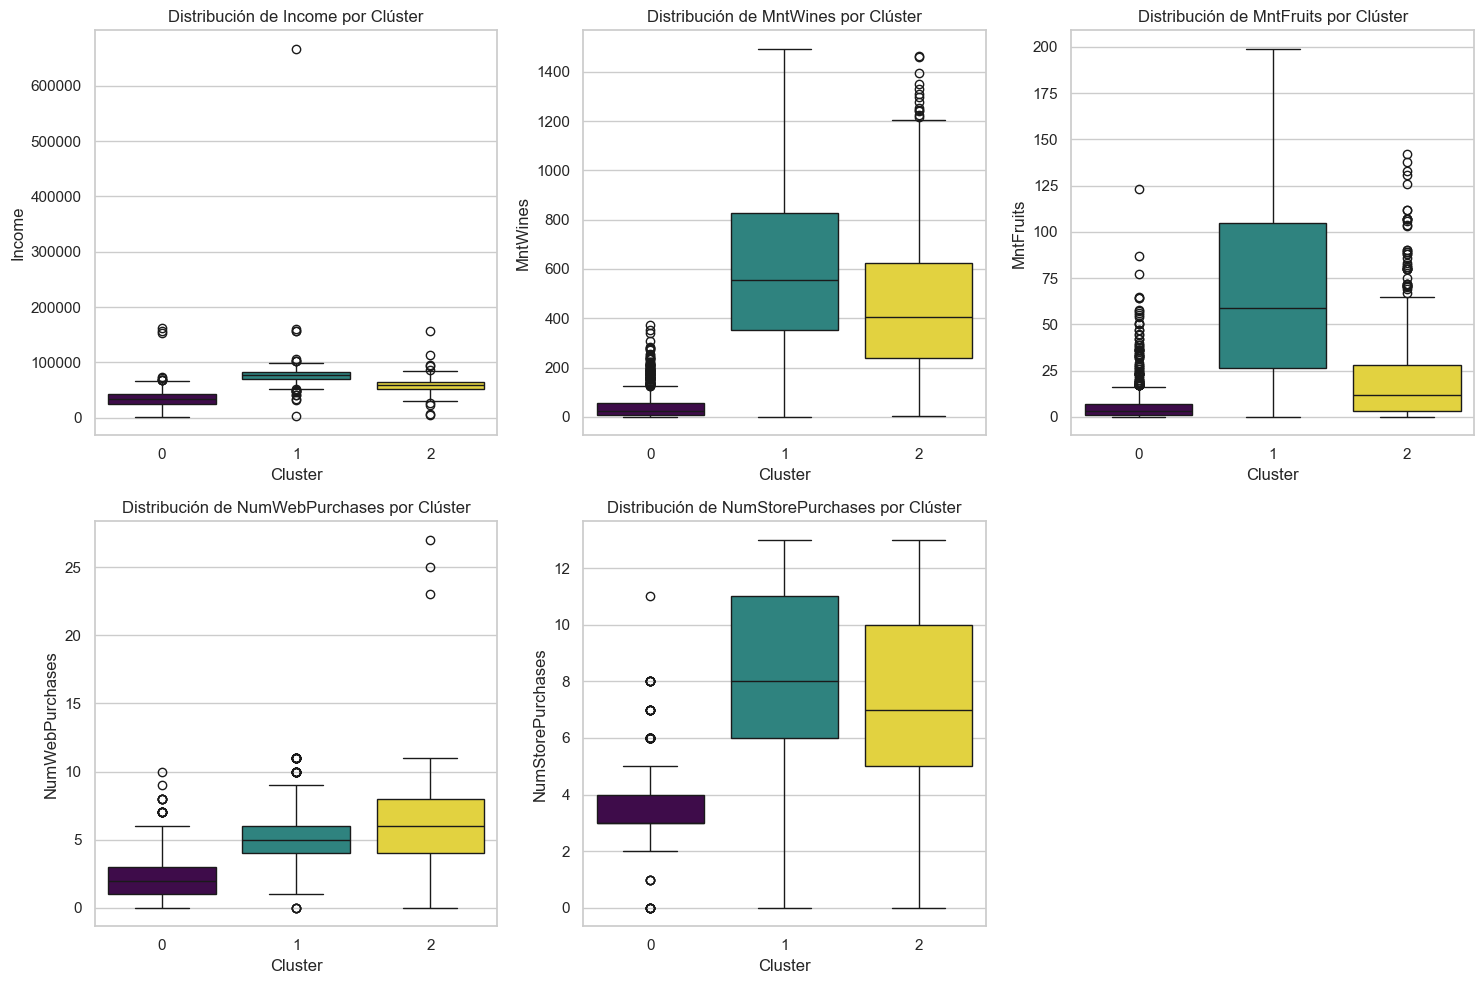

In [16]:
# Seleccionar variables clave para los boxplots
key_columns = ['Income', 'MntWines', 'MntFruits', 'NumWebPurchases', 'NumStorePurchases']

# Configurar el estilo de los gráficos
sns.set_theme(style="whitegrid")

# Crear boxplots para cada variable por clúster
plt.figure(figsize=(15, 10))
for i, column in enumerate(key_columns, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x='Cluster', y=column, data=df, hue='Cluster', palette='viridis', legend=False)
    plt.title(f'Distribución de {column} por Clúster')
    plt.xlabel('Cluster')
    plt.ylabel(column)
plt.tight_layout()
plt.show()